# 第五阶段 A：ANN 充电控制器的有界鲁棒性验证

## 本阶段回答什么问题

阶段 4B-2 只证明 ANN v2 在 25 ℃ 名义 Chen2020 DFN 工况上有效。本阶段不重新训练网络，而是冻结 ANN、安全过滤器和控制约束，检查它们面对参数偏差、初始条件变化和状态估计误差时是否仍能完成 10%–80% SOC 充电。

这里的 69 个降阶场景是**有界压力样本**，不是电芯制造分布，因此完成率不能解释为现场可靠度。高保真层只设置 15、25、30 ℃ 三个 Chen2020 DFN 锚点。

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs" / "phase5a.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

metrics = json.loads((PROJECT_ROOT / "outputs/metrics/phase5a_metrics.json").read_text(encoding="utf-8"))
reduced = pd.read_csv(PROJECT_ROOT / "data/phase5a/reduced_stress_summary.csv")
dfn = pd.read_csv(PROJECT_ROOT / "data/phase5a/dfn_temperature_anchor_summary.csv")
print("Phase 5A passed:", metrics["success"])
print("Ready for observer validation:", metrics["ready_for_observer_validation"])

Phase 5A passed: False
Ready for observer validation: False


## 验证域与固定门槛

降阶层包含：初始 SOC 0.10–0.30、环境温度 15–30 ℃、容量 ±10%、电阻 ±20%、时间常数 ±20%、热容 ±15%、热阻 ±20%、产热增益 ±10%，以及 SOC、温度和双极化电压的有偏相关噪声。

控制器使用名义参数，被控对象使用扰动参数。上一时刻电流是控制器已知的上一条指令，因此不人为添加传感器噪声。验收要求完成率至少 95%、物理安全率 100%、最长 60 min、实质安全层介入不超过 20%；三个 DFN 锚点必须全部安全完成。

In [2]:
cfg = metrics["configuration"]
display(pd.Series(cfg["reduced_stress_test"], name="declared value").to_frame())
display(pd.Series(cfg["success_criteria"], name="gate").to_frame())

,declared value
random_scenario_count,64
initial_soc_range,"[0.1, 0.3]"
ambient_temperature_c_range,"[15.0, 30.0]"
capacity_multiplier_range,"[0.9, 1.1]"
resistance_multiplier_range,"[0.8, 1.2]"
time_constant_multiplier_range,"[0.8, 1.2]"
heat_capacity_multiplier_range,"[0.85, 1.15]"
thermal_resistance_multiplier_range,"[0.8, 1.2]"
heat_gain_multiplier_range,"[0.9, 1.1]"
soc_bias_range,"[-0.005, 0.005]"


,gate
minimum_reduced_completion_fraction,0.95
minimum_reduced_physical_safety_fraction,1.0
maximum_reduced_charge_time_min,60.0
maximum_reduced_material_intervention_fraction,0.2
require_all_dfn_anchors_complete,True
require_all_dfn_anchors_physically_safe,True
maximum_dfn_anchor_charge_time_min,60.0
maximum_dfn_material_intervention_fraction,0.2


## 降阶压力测试总览

,result
scenario count,69.000
completion fraction [%],68.116
physical safety fraction [%],65.217
maximum charge time [min],60.000
maximum material intervention [%],55.833


,scenario_id,value
charge_time,corner_hot_resistive_optimistic,60.0
voltage,corner_cold_resistive,4.17032
temperature,corner_hot_resistive_optimistic,34.774421
material_intervention,corner_hot_resistive_optimistic,0.558333
terminal_soc_undercharge,corner_hot_resistive_optimistic,-0.281704
current_change,lhs_007,7.092329


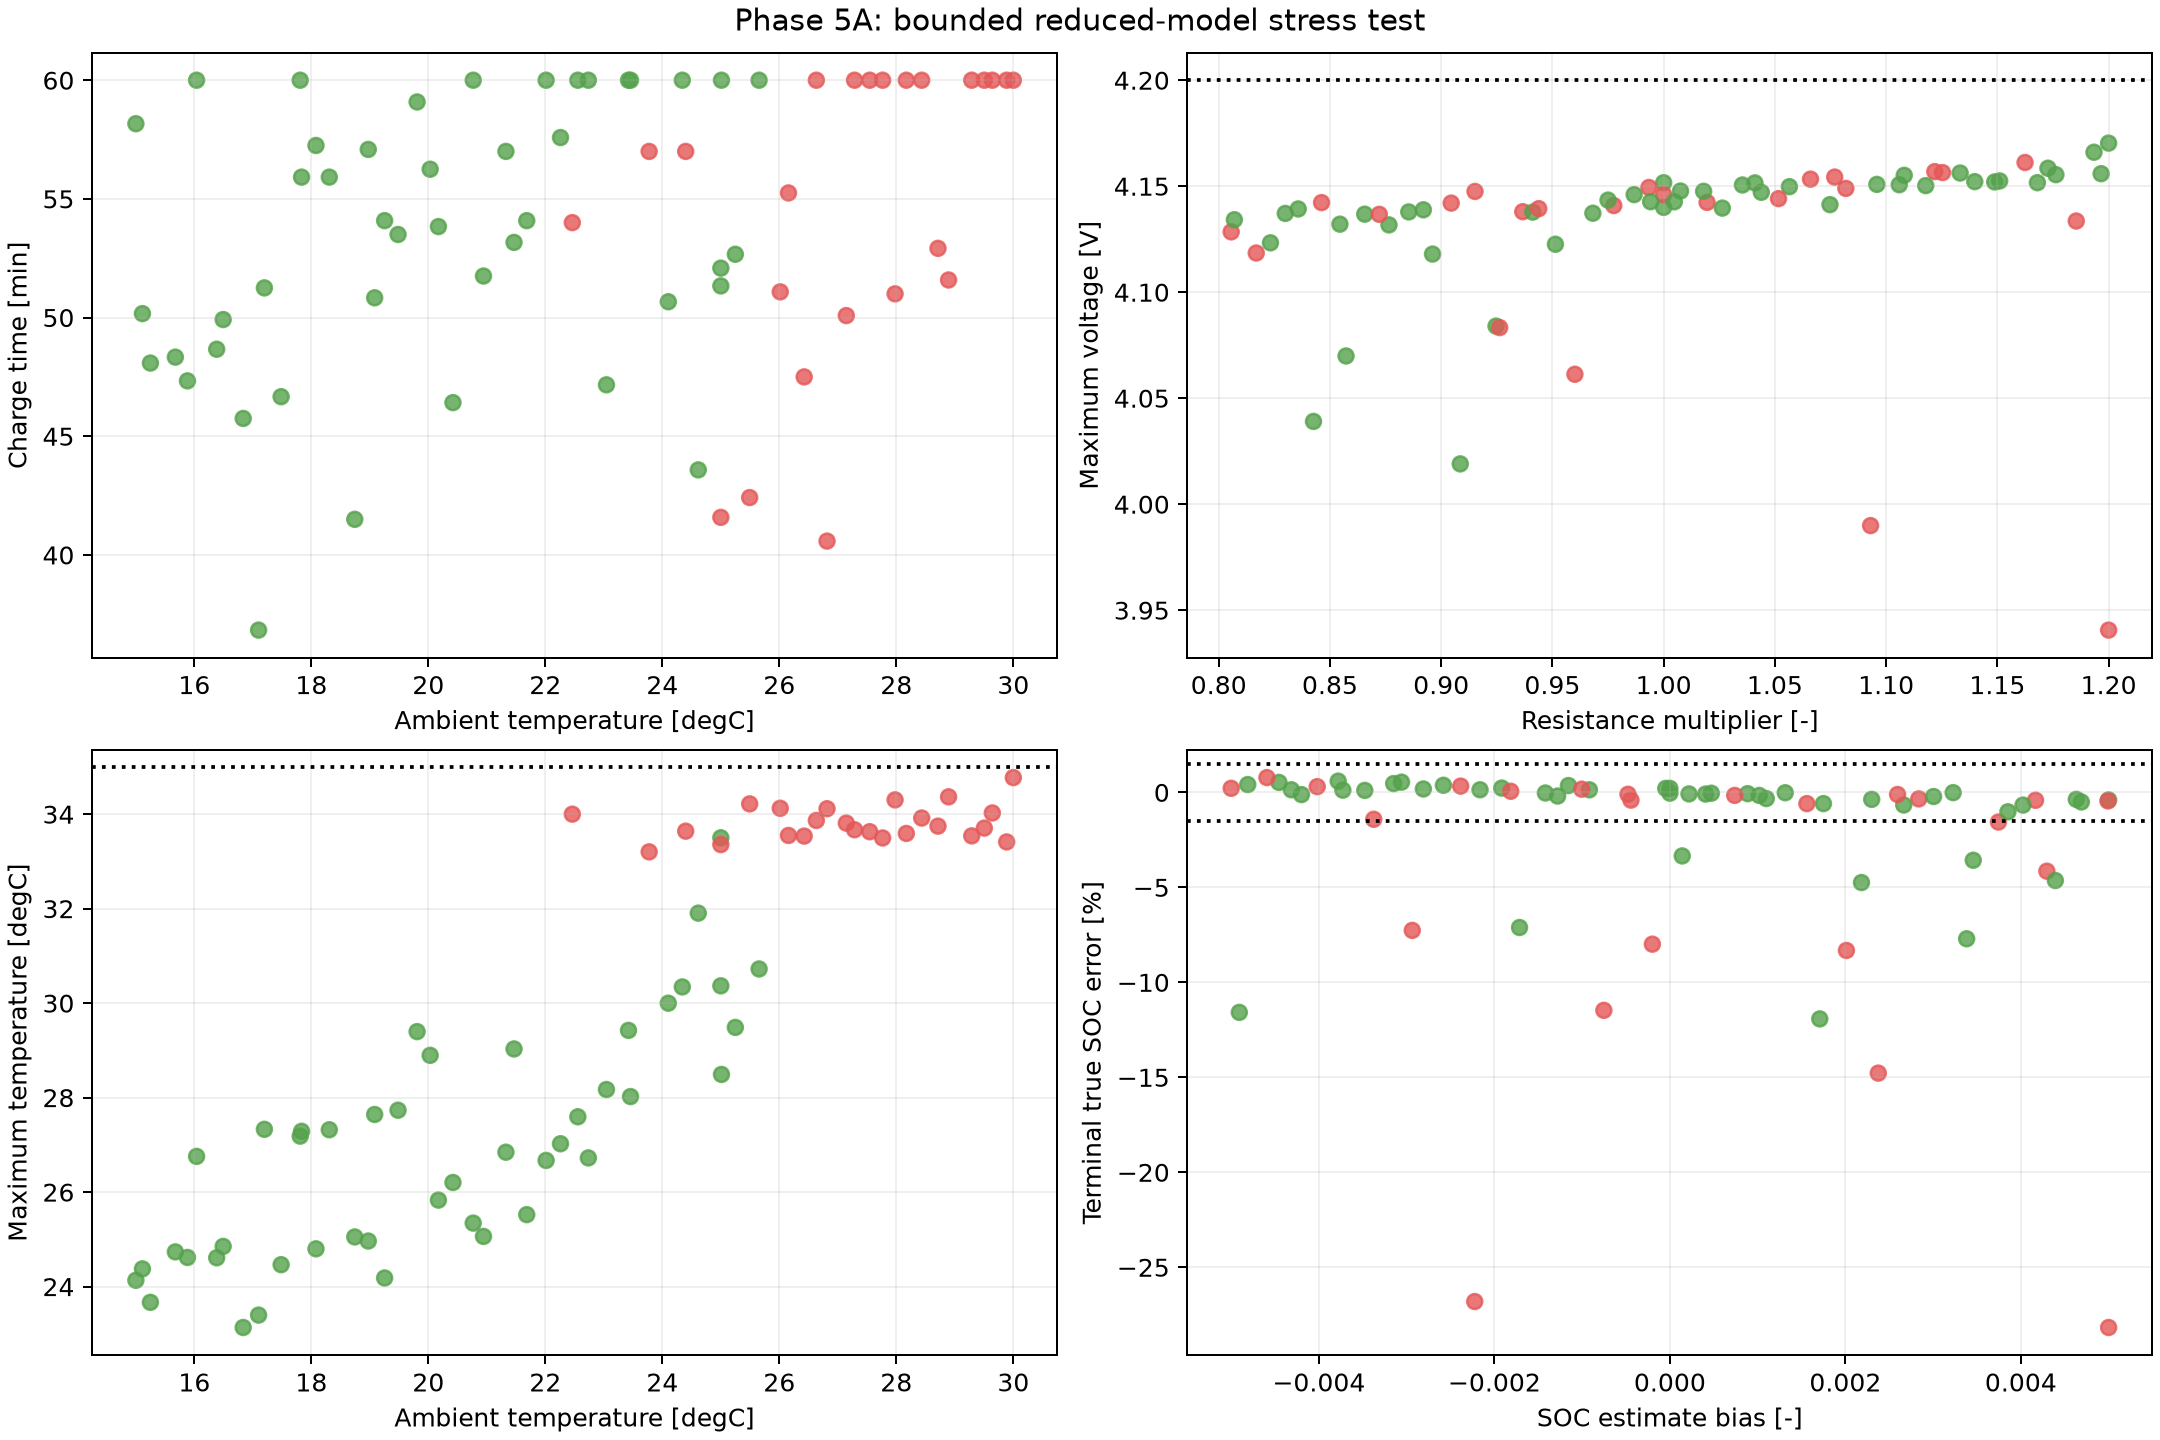

In [3]:
r = metrics["reduced_stress_test"]
display(pd.Series({
    "scenario count": r["scenario_count"],
    "completion fraction [%]": 100 * r["completion_fraction"],
    "physical safety fraction [%]": 100 * r["physical_safety_fraction"],
    "maximum charge time [min]": r["maximum_charge_time_min"],
    "maximum material intervention [%]": 100 * r["maximum_material_intervention_fraction"],
}, name="result").to_frame().round(3))
display(pd.DataFrame(r["worst_cases"]).T)
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/phase5a_reduced_stress_summary.png")))

69 个场景中只有 47 个同时满足控制器完成判定和真实终端 SOC 容差，完成率为 68.12%；45 个满足全部物理边界，安全率为 65.22%。两项都低于门槛。

最坏高温高内阻角点在 60 min 时仍欠 28.17% SOC，最高平均温度达到 34.77 ℃。部分接近热边界的场景中，安全层需要把电流快速降为 0，最大单步变化达到 7.09 A，超过 2 A 约束。这不是停机点记账造成的假象，而是“继续保持温度安全”和“限制电流斜率”在当前策略下发生冲突。

## Chen2020 DFN 三温度锚点

,anchor_temperature_c,reached_target_soc,final_soc,charge_time_min,maximum_voltage_v,maximum_temperature_c,maximum_current_change_a,material_safety_filter_intervention_fraction,success
0,15.0,True,0.7995,56.0833,4.1592,24.3631,2.0000,0.1293,True
1,25.0,True,0.7999,52.7500,4.1426,33.5024,2.0000,0.0158,True
2,30.0,False,0.6122,NaN,3.9634,33.5038,3.3631,0.9139,False


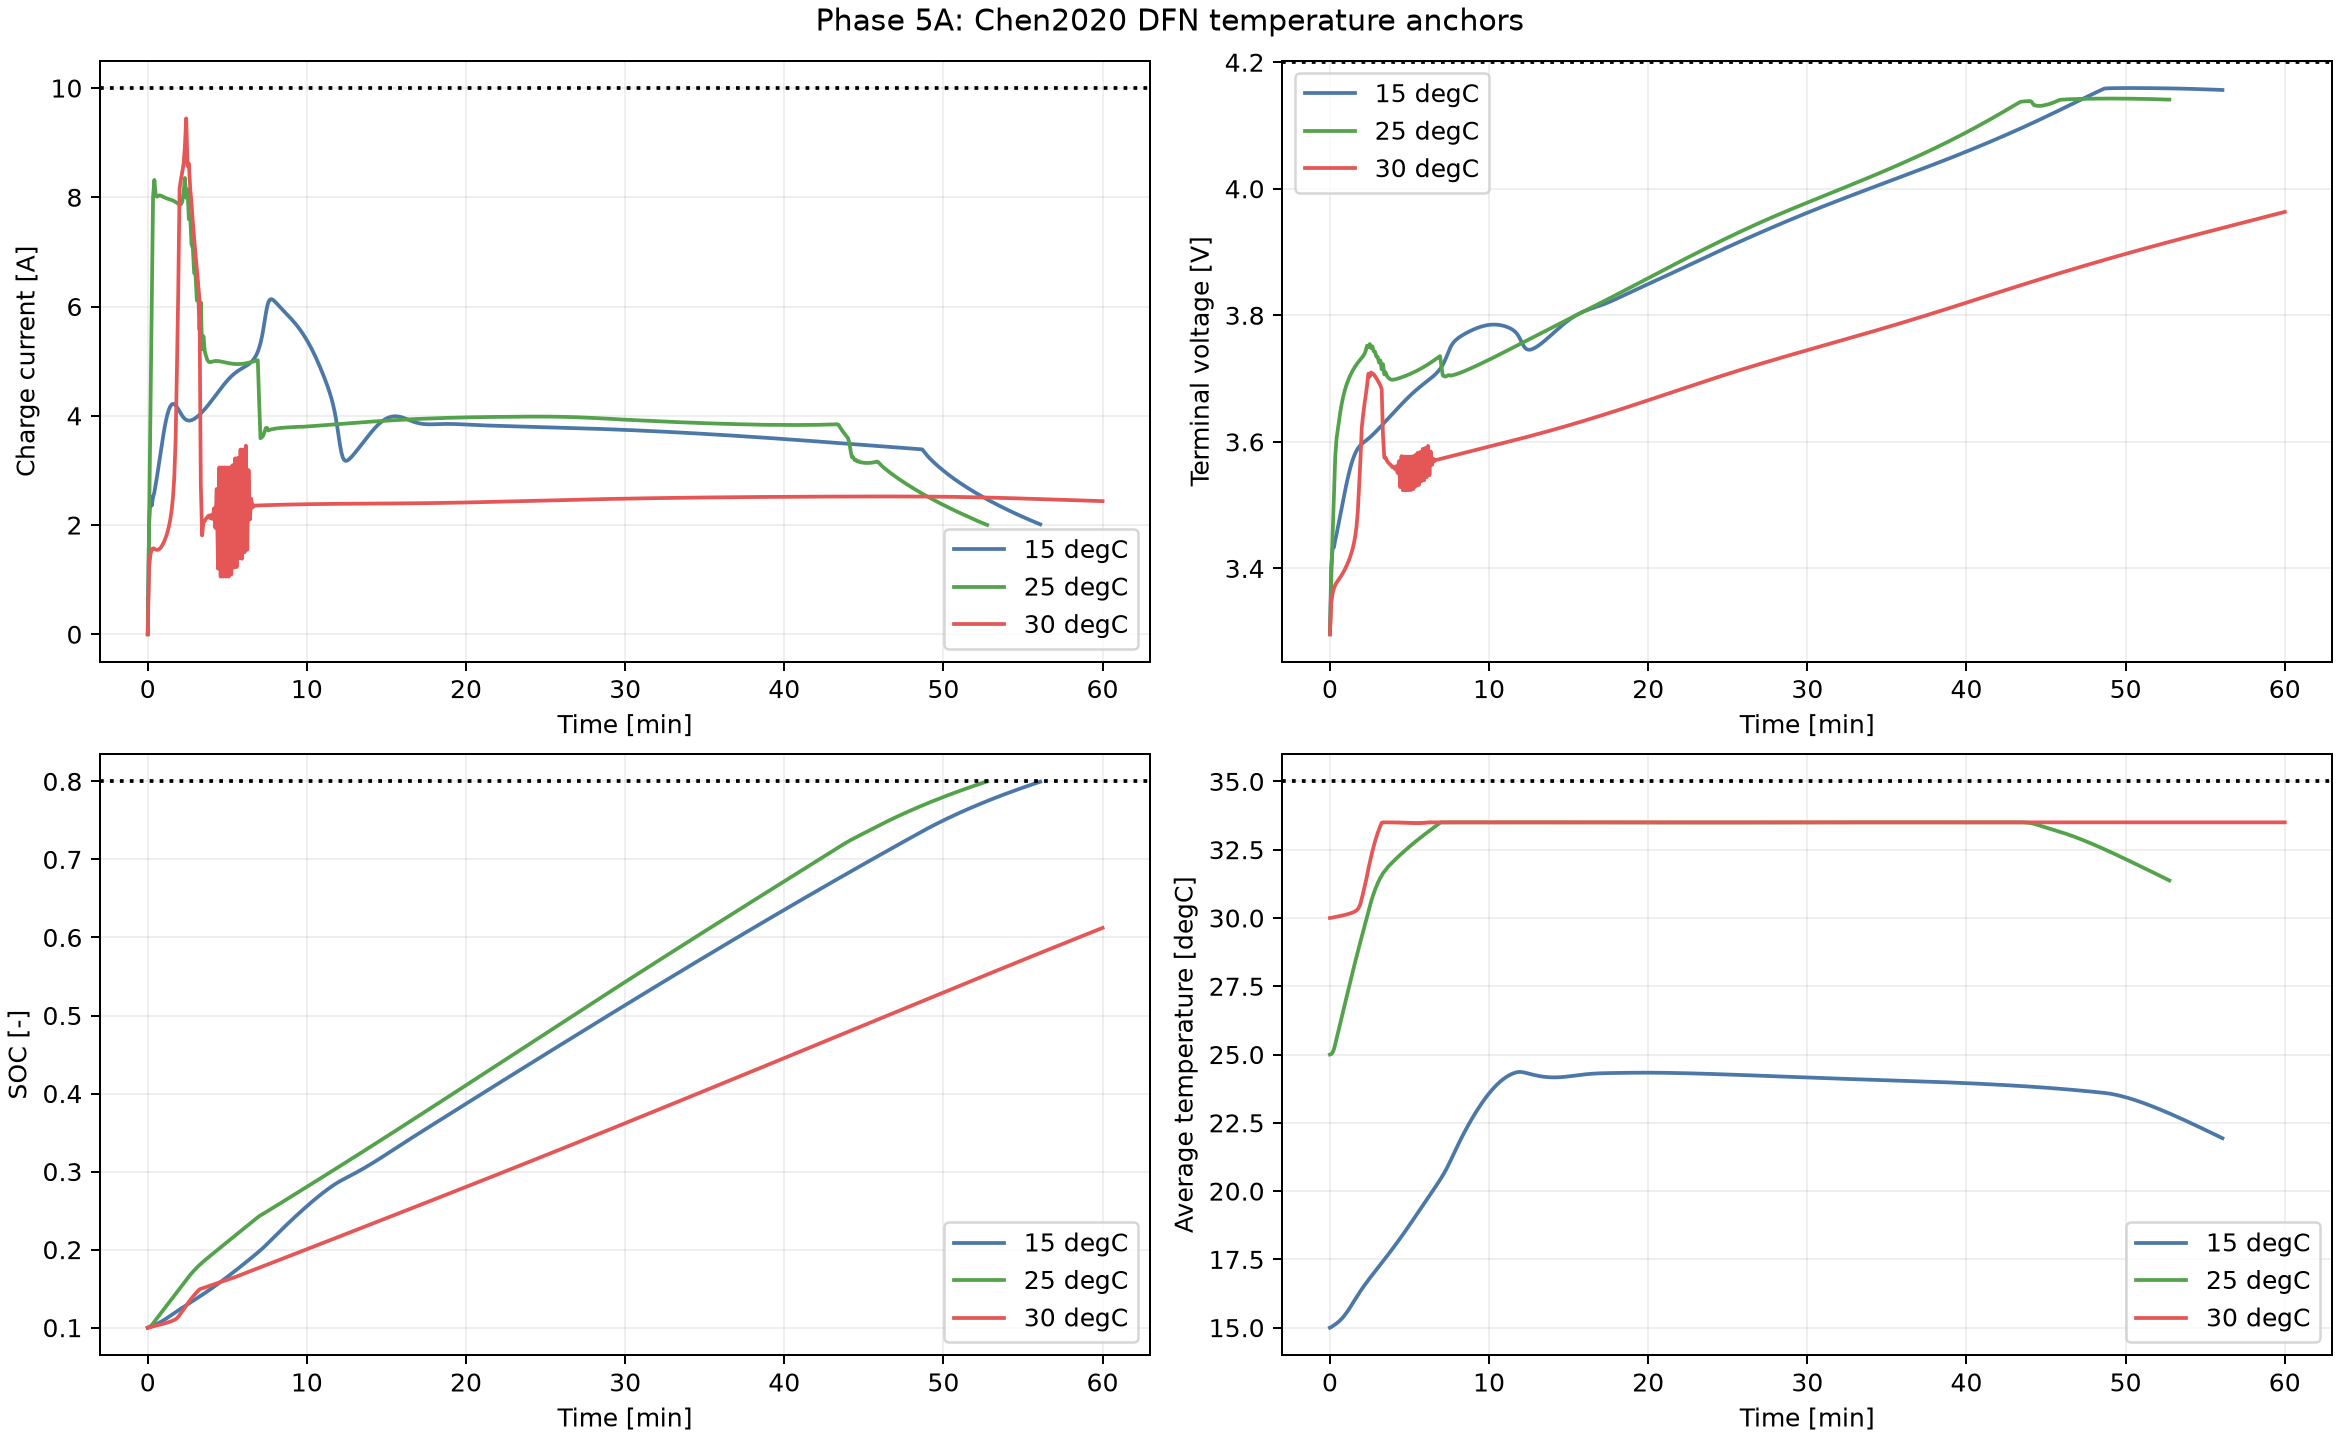

In [4]:
columns = [
    "anchor_temperature_c", "reached_target_soc", "final_soc", "charge_time_min",
    "maximum_voltage_v", "maximum_temperature_c", "maximum_current_change_a",
    "material_safety_filter_intervention_fraction", "success",
]
display(dfn[columns].round(4))
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/phase5a_dfn_temperature_anchors.png")))

15 ℃ 和 25 ℃ 锚点都到达 80% SOC，分别需要 56.08 min 和 52.75 min，且没有电压、温度、电流或斜率越界。

30 ℃ 锚点没有完成：60 min 后 SOC 只有 61.22%。平均温度贴近 33.5 ℃ 收紧边界后，安全过滤器在 91.39% 的控制步发生超过 0.1 A 的实质修正，并出现 3.36 A 单步变化。它说明 ANN 的训练数据主要覆盖 25 ℃ 名义闭环，缺少高温热预算耗尽区域的可行减流策略。

## 门槛判断与下一步

In [5]:
display(pd.DataFrame({
    "reduced stress": metrics["reduced_stress_test"]["checks"],
    "DFN anchors": metrics["dfn_temperature_anchors"]["checks"],
}).fillna("-") )
display(pd.Series(metrics["checks"], name="passed").to_frame())

,reduced stress,DFN anchors
completion_fraction,False,-
physical_safety_fraction,False,-
maximum_charge_time,True,False
maximum_material_intervention,False,False
all_anchors_complete,-,False
all_anchors_physically_safe,-,False


,passed
reduced_stress_test,False
dfn_temperature_anchors,False


Phase 5A 未通过，因此现在不应直接进入 BMS 接口或把 ANN 当作独立控制器。下一步应是 **Phase 5B：高温与参数扰动域的教师数据扩展**：

1. 在 27–30 ℃、高内阻和热参数不利组合中，用约束教师重新生成可行的提前减流轨迹；
2. 把温度余量或环境温度显式加入控制状态，避免只依赖当前平均温度才开始急停；
3. 重新聚合数据并训练 ANN v3；
4. 原样复用本阶段门槛，不降低 33.5 ℃、2 A/步或完成率要求；
5. ANN v3 通过同一压力测试后，再开展 SOC/温度/极化状态观测器的实现验证。

本结论只涉及平均温度。Chen2020 参数仍不支持可信的极耳或局部热点空间热验证。